1. Importar as bibliotecas

In [44]:
# Importação das bibliotecas que utilizaremos
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns

2. Definir a variável "file" pelo nome da planilha.

In [45]:
# Importação do arquivo de tabela a ser utilizado, através do path na seção "Files" do Colab, contendo as informações de resíduos sólidos
file='./Solid_waste_pt.xlsx'

3. Ler a planilha no Python.

In [46]:
# Visão geral da tabela
df=pd.read_excel(file)
df

,Regiao_Coleta,Tipo_Residuo,Origem_Residuo,Metodo_Destinacao,Massa_Coletada_kg,Densidade_Residuo_kgm3,Umidade_Residuo_pct,Distancia_Destinacao_km,Custo_Coleta_Transporte_RS_ton,Indice_Reciclabilidade_pct,Poder_Calorifico_MJkg
0,Zona Sul,Reciclável,Comercial,Aterro Sanitário,1057.3,80.8,2.0,14.7,138.7,79.7,15.1
1,Zona Oeste,Reciclável,Comercial,Reciclagem,533.3,82.4,2.0,9.1,119.1,85.4,17.9
2,Centro,Reciclável,Comercial,Reciclagem,529.7,72.7,2.0,24.0,223.2,81.6,13.9
3,Zona Oeste,Reciclável,Comercial,Reciclagem,486.3,67.4,2.0,3.6,117.9,82.0,18.8
4,Zona Leste,Reciclável,Comercial,Aterro Sanitário,527.1,40.0,2.0,16.7,164.2,88.0,14.7
...,...,...,...,...,...,...,...,...,...,...,...
285,Zona Leste,Orgânico,Residencial,Aterro Sanitário,275.9,371.8,77.0,17.2,178.8,5.2,6.5
286,Zona Norte,Orgânico,Comercial,Aterro Sanitário,471.8,338.4,77.2,52.9,262.3,5.0,8.1
287,Zona Leste,Orgânico,Residencial,Aterro Sanitário,356.3,341.2,77.6,18.0,184.2,10.1,3.6
288,Zona Oeste,Orgânico,Comercial,Reciclagem,674.9,316.9,78.5,5.1,94.1,8.1,8.8


In [47]:
classes = [0,25,50,75,100]
coluna='Umidade_Residuo_pct'
frequencia_pct_umidade = pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False))
frequencia_pct_umidade.sort_index(ascending=True)

/tmp/ipykernel_2010/1114184605.py:3: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  frequencia_pct_umidade = pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False))


,count
Umidade_Residuo_pct,
"[0, 25)",121
"[25, 50)",50
"[50, 75)",110
"[75, 100)",9


In [48]:
frequencia_relativa_pct_umidade=round(pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False),normalize=True)*100,2)
frequencia_relativa_pct_umidade.sort_index(ascending=True)

/tmp/ipykernel_2010/891510522.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  frequencia_relativa_pct_umidade=round(pd.value_counts(pd.cut(x=df[coluna],bins=classes,include_lowest=True,right=False),normalize=True)*100,2)


,proportion
Umidade_Residuo_pct,
"[0, 25)",41.72
"[25, 50)",17.24
"[50, 75)",37.93
"[75, 100)",3.10


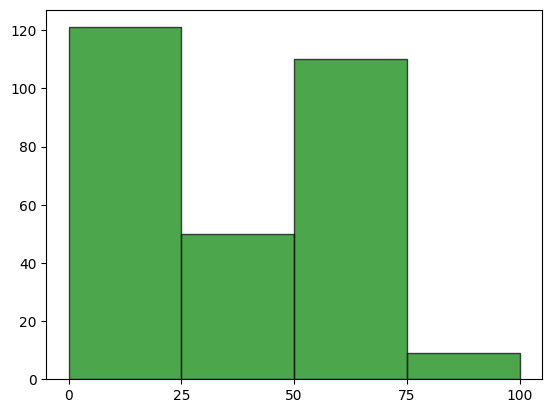

In [49]:
classes=range(0,125,25)
plt.hist(df.Umidade_Residuo_pct,bins=classes,rwidth=1, color='green', alpha=0.7, edgecolor='black')
# Set the tick locations and corresponding labels
plt.xticks(ticks=[0, 25, 50, 75, 100], labels=['0', '25', '50', '75', '100'], rotation=0)
plt.show()

**Histograma**

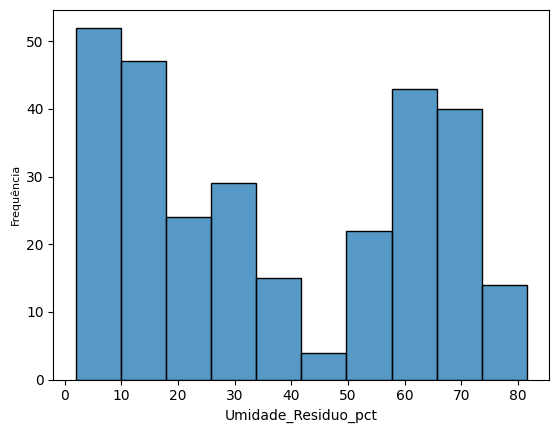

In [50]:
sns.histplot(data=df,x="Umidade_Residuo_pct",kde=False)
plt.ylabel("Frequência",size=8)
plt.show()

VALORES MÍNIMO E MÁXIMO DO CONJUNTO DE DADOS.

In [51]:
valormin=min(df.Umidade_Residuo_pct)
valormax=max(df.Umidade_Residuo_pct)
valormin,valormax

(2.0, 81.6)

**Medidas de Tendência Central**


*   Média, Moda e Mediana


In [52]:
#cálculo da Média, indicando Dataframe e a coluna em questão, no exemplo df.Umidade_Residuo_pct
df.Umidade_Residuo_pct.mean()

np.float64(37.009655172413794)

In [53]:
# com 2 casas decimais
df.Umidade_Residuo_pct.mean().round(2)

np.float64(37.01)

In [54]:
# cálculo da moda. Mesmas indicações
df.Umidade_Residuo_pct.mode()

,Umidade_Residuo_pct
0,2.0


In [55]:
#cálculo da mediana.
df.Umidade_Residuo_pct.median()

32.3

In [56]:
#comando describe mostra várias medidas das variáveis quantitativas, incluindo média e mediana.
df.Umidade_Residuo_pct.describe().round(2)

,Umidade_Residuo_pct
count,290.00
mean,37.01
std,25.23
min,2.00
25%,13.92
50%,32.30
75%,62.12
max,81.60


In [59]:
tabela_umidade_residuos = pd.DataFrame({
    'Frequência Absoluta': frequencia_pct_umidade,
    'Frequência Relativa (%)': frequencia_relativa_pct_umidade
})

tabela_umidade_residuos = tabela_umidade_residuos.reset_index()
tabela_umidade_residuos = tabela_umidade_residuos.rename(columns={'Umidade_Residuo_pct': 'Intervalos'})

display(tabela_umidade_residuos)

,Intervalos,Frequência Absoluta,Frequência Relativa (%)
0,"[0, 25)",121,41.72
1,"[50, 75)",110,37.93
2,"[25, 50)",50,17.24
3,"[75, 100)",9,3.10


In [62]:
tabela_umidade_residuos.to_excel("Tabela_Frequencia_Umidade.xlsx", sheet_name="Dados", index=False)
